In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot
from scipy.integrate import odeint
from scipy.optimize import least_squares, minimize
from ITIS_Model_funcs import get_nominal_param, ITIS, OLS_res
import pickle
from profile_likelihood_parallel_funcs import calc_PL_fixpar_parallel


In [2]:
paramtitles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

stateTitles = ['Endotoxin', 'Phagocytes', 'TGF-\u03b2','TNF-\u03B1','IL10','CRH','ACTH','Cortisol']

In [3]:
param_log,IC = get_nominal_param()

##Define time spaces
tstart = 0
t_end =24*8
dt = .05
tspace = np.arange(tstart,t_end,dt)
tfinal = np.arange(0,24+dt,dt)

##Solve the model at nominal values
ode_options = {'rtol': 1e-6}
ODE_sol = odeint(ITIS, IC, tspace, args = (param_log,), **ode_options)

# MJC - this is where we can specify that the infection begins during this final time point
IC_2    = ODE_sol[-1,:]
IC_2[0] = 2.0
# Resolve model only over 24 hours at subsampled time points. This will be used as our data
true_sol = odeint(ITIS, IC_2, tfinal, args = (param_log,), **ode_options)


# t_data = np.linspace(0,24,24+1) # time points every hour
# t_data = np.linspace(0,24,12+1) # less data, every 30 minutes

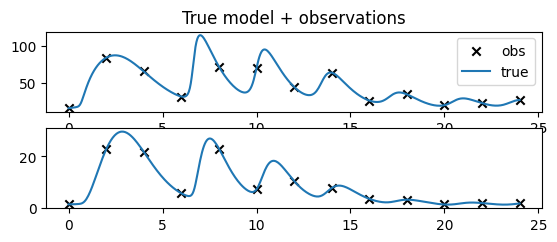

In [4]:
#Generate data
output_ids = [6, 7] # Neuroendocrine = ACTH + Cort
#output_ids = [3, 6, 7] # TNF + ACTH + Cort
# output_ids = [3,4,6,7] #TNF + IL10 + ACTH + Cort

##use generated sets instead
with open('syntheticData\\TRUE_SOL_13.pkl', 'rb') as f:
    results = pickle.load(f)
y_data = results['y_data'].copy()
t_data = results['t_data'].copy()

plt.figure()
plt.subplot(4,1,1)
plt.scatter(t_data,y_data[:,0],marker='x',color='k',label='obs')
plt.plot(tfinal,true_sol[:,output_ids[0]],label='true')
plt.title('True model + observations')
plt.legend()
#
plt.subplot(4,1,2)
plt.scatter(t_data,y_data[:,1],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[1]])

# plt.subplot(4,1,3)
# plt.scatter(t_data,y_data[:,2],marker='x',color='k')
# plt.plot(tfinal,true_sol[:,output_ids[2]])

# plt.subplot(4,1,4)
# plt.scatter(t_data,y_data[:,3],marker='x',color='k')
# plt.plot(tfinal,true_sol[:,output_ids[3]])

plt.show()


In [5]:
# Define which parameters will be updated

##MOST SENSITIVE FOR ACTH + CORT
# param_ids = [33, 12, 36, 43, 32, 39, 7, 16, 31, 15, 37, 9, 8, 28, 14]
param_ids = np.sort([33, 12, 36, 43, 32, 39, 7, 16, 31, 15, 37, 9, 8, 28, 14])
# param_ids = param_ids[0:3]
##MOST SENSITIVE FOR ACTH + CORT + TNF-A
#param_ids = [33,12,36,32,7,34,31,15,8,9,16,14,28,26,1]
##MOST SENSITIVE FOR ACTH + CORT + TNF-A + 1L10
# param_ids = [12, 33, 7, 16, 36, 43, 39, 15, 32, 31, 22, 8, 9, 14, 21, 10, 1]
#D1 Selected:
#D2 Selected: [12, 33, 16, 7, 36, 43, 32, 39, 15, 8, 31, 14, 9, 34]
#       ['h6', 'd7', 'd4', 'k3', 'd8', 'T', 'h11', 'beta', 'h7', 'k4', 'k14', 'k6', 'h4', 'k15']
#D3 Selected: [12, 33, 7, 16, 36, 43, 39, 15, 32, 31, 22, 8, 9, 14, 21, 10, 1]
#   ['h6', 'd7', 'k3', 'd4', 'd8', 'T', 'beta', 'h7', 'h11', 'k14', 'd5', 'k4', 'h4', 'k6', 'h9', 'd3', 'k1']

# MJC - make these bounds based on the parameter values
UB = np.log(np.exp(param_log[param_ids])*10)
LB =  np.log(np.exp(param_log[param_ids])*0.001)
bounds = np.array([LB,UB]).T


In [6]:
def ols_call(x):
    r = OLS_res(x,y_data,t_data,param_ids,output_ids,param_log,IC)
    return(r)


par_fix = np.round(np.linspace(0,int(len(param_log)-1),int(len(param_log))))
par_fix = np.delete(par_fix,param_ids)
print(par_fix)
print(param_ids)

[ 0.  1.  2.  3.  4.  5.  6. 10. 11. 13. 17. 18. 19. 20. 21. 22. 23. 24.
 25. 26. 27. 29. 30. 34. 35. 38. 40. 41. 42. 44.]
[ 7  8  9 12 14 15 16 28 31 32 33 36 37 39 43]


In [ ]:
J_save, par_save, param_global_all = calc_PL_fixpar_parallel(ols_call,
    params=param_log[param_ids],
    bounds=bounds,
    par_fix=[],
    N=101,
    profile_width=0.5,
    max_nfev=300,
    finite_diff_step=1e-4,
    verbose=True,
    n_jobs=12)

Profiling parameter 1 of 15
Profiling parameter 2 of 15
Profiling parameter 3 of 15
Profiling parameter 4 of 15
Profiling parameter 5 of 15
Profiling parameter 6 of 15
Profiling parameter 7 of 15
Profiling parameter 8 of 15
Profiling parameter 9 of 15
Profiling parameter 10 of 15
Profiling parameter 11 of 15
Profiling parameter 12 of 15


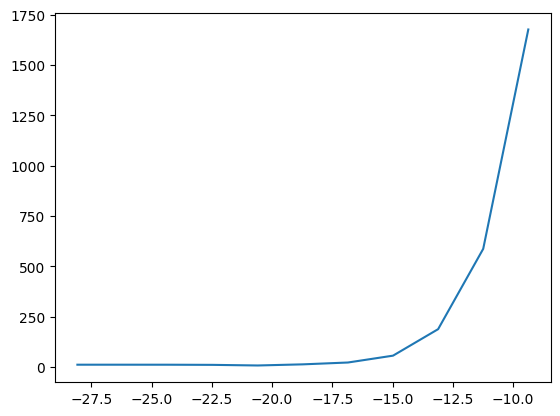

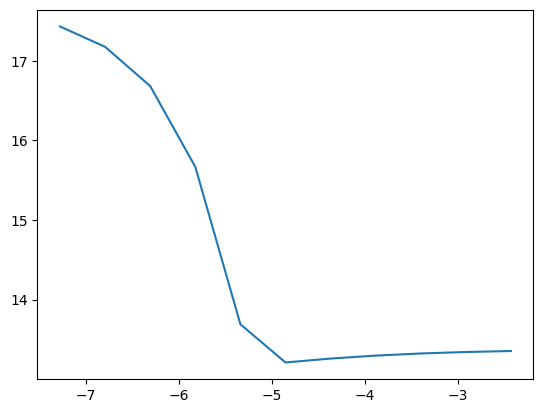

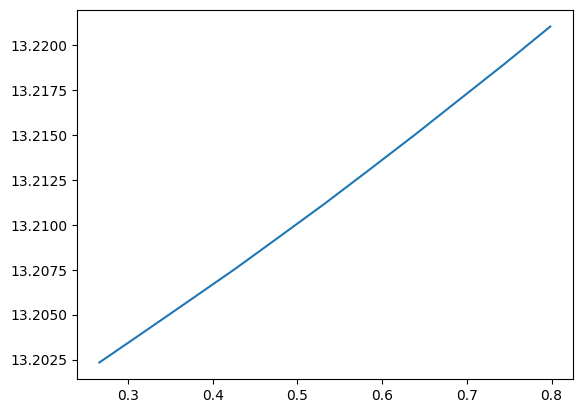

In [20]:
plt.figure()
plt.plot(par_save[0,0,:],J_save[0,:])
plt.show()

plt.figure()
plt.plot(par_save[1,1,:],J_save[1,:])
plt.show()

plt.figure()
plt.plot(par_save[2,2,:],J_save[2,:])
plt.show()

In [ ]:
import pickle

all_results = {
    'param_ids' : param_ids,
    't_data' : t_data,
    'y_data' : y_data,
    'true_sol' : true_sol,
    'J_save': J_save,
    'par_save': par_save,
    'param_global_all': param_global_all
}

with open('PL_D1_13_nonoise.pkl', 'wb') as f:
    pickle.dump(all_results, f)
# J_save, par_save, param_global_all

NameError: name 'output_ids' is not defined